# Jalon 5, 6 & 7 — Deep Learning Fondamental

## Jalon 5 — Architecture : pourquoi un MLP ?

| Architecture | Cas d'usage | Ce dataset |
|---|---|---|
| **MLP** | Données tabulaires, pas de structure spatiale ou séquentielle | **OUI** — 19 features indépendantes |
| **CNN** | Images, signaux avec localité spatiale (filtres coulissants) | NON — pas de matrice 2D |
| **RNN/LSTM** | Séquences temporelles **par individu** | NON pour les features, OUI pour la série temporelle pays×année (→ Jalon 8) |

Le MLP est l'architecture naturelle pour des données tabulaires : chaque neurone du layer d'entrée correspond à une feature, les connexions denses apprennent les interactions non-linéaires.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import joblib
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from src.preprocessing import load_data, prepare_ml, FEATURES
from src.models_dl import MLP, make_loaders, train_mlp, predict_mlp, plot_training_history
from src.evaluation import regression_metrics, compare_models, plot_predictions, bias_variance_analysis

plt.rcParams['figure.dpi'] = 110

df = load_data('../data/tiktok_instagram_global_100countries.csv')
X_train, X_test, y_train, y_test, scaler, le = prepare_ml(df)

INPUT_DIM = X_train.shape[1]
print(f'Input dim : {INPUT_DIM} | Device : {"cuda" if torch.cuda.is_available() else "cpu"}')

Input dim : 18 | Device : cpu


## Jalon 5 — Architecture MLP (baseline DL)

Architecture choisie : **256 → 128 → 64 → 1**
- **BatchNorm** après chaque couche linéaire : normalise les activations pour éviter le vanishing gradient
- **ReLU** : fonction d'activation non-saturante (gradient constant pour x > 0)
- **Dropout(0.3)** : régularisation, réduit l'overfitting

In [2]:
model_baseline = MLP(INPUT_DIM, hidden_dims=(256, 128, 64), dropout=0.3)
print(model_baseline)
n_params = sum(p.numel() for p in model_baseline.parameters() if p.requires_grad)
print(f'\nNombre de paramètres entraînables : {n_params:,}')

MLP(
  (net): Sequential(
    (0): Linear(in_features=18, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=64, out_features=1, bias=True)
  )
)

Nombre de paramètres entraînables : 46,977


Epoch 25/150 — Train MSE: 37.1973 | Val MSE: 1.1694


Epoch 50/150 — Train MSE: 33.3962 | Val MSE: 1.7967


Epoch 75/150 — Train MSE: 32.0207 | Val MSE: 2.6636


Epoch 100/150 — Train MSE: 30.4300 | Val MSE: 1.1265


Epoch 125/150 — Train MSE: 30.6374 | Val MSE: 0.7149


Epoch 150/150 — Train MSE: 30.8359 | Val MSE: 0.8133


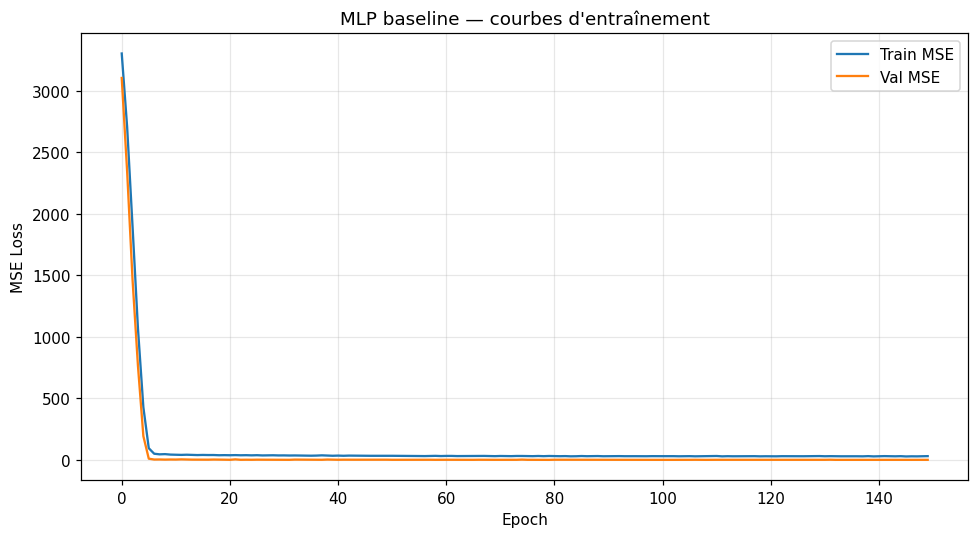

In [3]:
train_loader, val_loader = make_loaders(X_train, y_train, X_test, y_test, batch_size=64)

model_baseline, history_baseline = train_mlp(
    model_baseline, train_loader, val_loader,
    epochs=150, lr=1e-3, weight_decay=1e-4
)

fig = plot_training_history(history_baseline, 'MLP baseline — courbes d\'entraînement')
plt.show()

In [4]:
y_pred_mlp_base = predict_mlp(model_baseline, X_test)
metrics_mlp_base = regression_metrics(y_test, y_pred_mlp_base, 'MLP_baseline')
print(metrics_mlp_base)

{'model': 'MLP_baseline', 'R²': 0.9903, 'RMSE': np.float64(0.9048), 'MAE': 0.7167}


## Jalon 6 — Optimisation des hyperparamètres

### 6.1 Stratégie anti-Vanishing/Exploding Gradient

| Problème | Solution implémentée |
|---|---|
| Vanishing gradient | BatchNorm (normalise les activations) + ReLU (gradient non nul pour x>0) |
| Exploding gradient | Gradient clipping (`clip_grad_norm_`, seuil=1.0) dans la boucle d'entraînement |
| Overfitting | Dropout + weight_decay (L2 implicite dans Adam) |

### 6.2 Recherche d'hyperparamètres avec Optuna

In [5]:
from sklearn.metrics import r2_score

def objective(trial):
    n_layers = trial.suggest_int('n_layers', 2, 4)
    hidden = tuple(
        trial.suggest_categorical(f'h{i}', [64, 128, 256, 512])
        for i in range(n_layers)
    )
    dropout = trial.suggest_float('dropout', 0.1, 0.5)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    wd = trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True)

    model = MLP(INPUT_DIM, hidden_dims=hidden, dropout=dropout)
    tl, vl = make_loaders(X_train, y_train, X_test, y_test, batch_size=64)
    model, _ = train_mlp(model, tl, vl, epochs=60, lr=lr, weight_decay=wd)

    y_pred = predict_mlp(model, X_test)
    return r2_score(y_test, y_pred)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20, show_progress_bar=True)

print(f'\nMeilleurs hyperparamètres :')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')
print(f'Meilleur R² : {study.best_value:.4f}')

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch 25/60 — Train MSE: 10.1482 | Val MSE: 1.5881


Epoch 50/60 — Train MSE: 8.1126 | Val MSE: 0.6626


Epoch 25/60 — Train MSE: 31.8745 | Val MSE: 9.1898


Epoch 50/60 — Train MSE: 25.3068 | Val MSE: 5.7213


...

Epoch 25/60 — Train MSE: 7.2979 | Val MSE: 1.9299


Epoch 50/60 — Train MSE: 5.7946 | Val MSE: 4.5734


Epoch 25/60 — Train MSE: 37.7877 | Val MSE: 1.3312


Epoch 50/60 — Train MSE: 33.2382 | Val MSE: 1.2359



Meilleurs hyperparamètres :
  n_layers: 4
  h0: 256
  h1: 64
  h2: 512
  h3: 64
  dropout: 0.13109517415807734
  lr: 0.0015662147016071968
  weight_decay: 0.0002856224065836008
Meilleur R² : 0.9965


### 6.3 Entraînement du meilleur modèle trouvé par Optuna

Epoch 25/200 — Train MSE: 15.8002 | Val MSE: 1.0416


Epoch 50/200 — Train MSE: 15.4298 | Val MSE: 1.3081


Epoch 75/200 — Train MSE: 12.7726 | Val MSE: 1.2491


Epoch 100/200 — Train MSE: 11.8843 | Val MSE: 0.6779


Epoch 125/200 — Train MSE: 13.1328 | Val MSE: 0.2745


Epoch 150/200 — Train MSE: 11.2212 | Val MSE: 1.0135


Epoch 175/200 — Train MSE: 11.9542 | Val MSE: 0.3729


Epoch 200/200 — Train MSE: 11.7305 | Val MSE: 0.5782
{'model': 'MLP_optimisé', 'R²': 0.9931, 'RMSE': np.float64(0.7628), 'MAE': 0.4742}


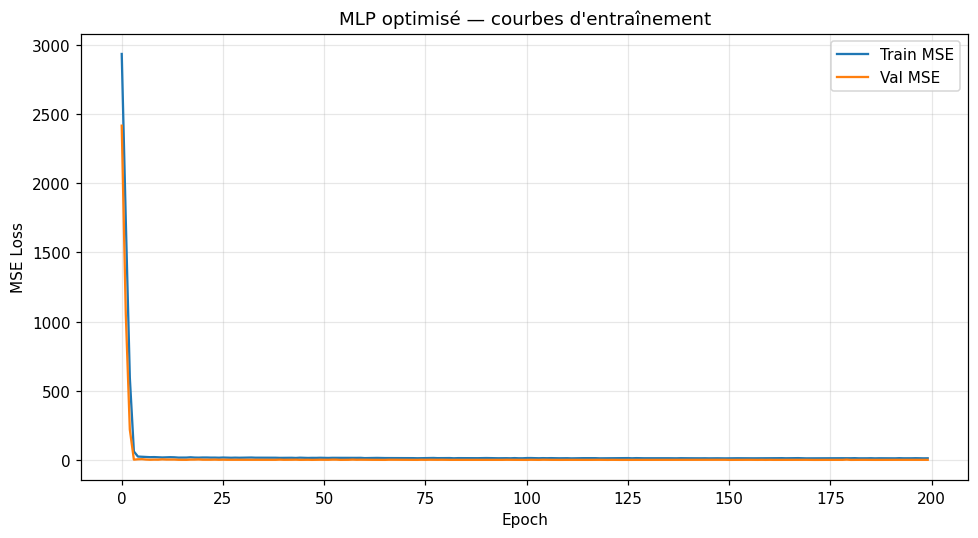

In [6]:
best = study.best_params
n_l = best['n_layers']
best_hidden = tuple(best[f'h{i}'] for i in range(n_l))

model_opt = MLP(INPUT_DIM, hidden_dims=best_hidden, dropout=best['dropout'])
tl, vl = make_loaders(X_train, y_train, X_test, y_test, batch_size=64)
model_opt, history_opt = train_mlp(
    model_opt, tl, vl,
    epochs=200, lr=best['lr'], weight_decay=best['weight_decay']
)

y_pred_mlp_opt = predict_mlp(model_opt, X_test)
metrics_mlp_opt = regression_metrics(y_test, y_pred_mlp_opt, 'MLP_optimisé')
print(metrics_mlp_opt)

fig = plot_training_history(history_opt, 'MLP optimisé — courbes d\'entraînement')
plt.show()

### 6.4 Comparaison des optimiseurs (Adam vs SGD+momentum)

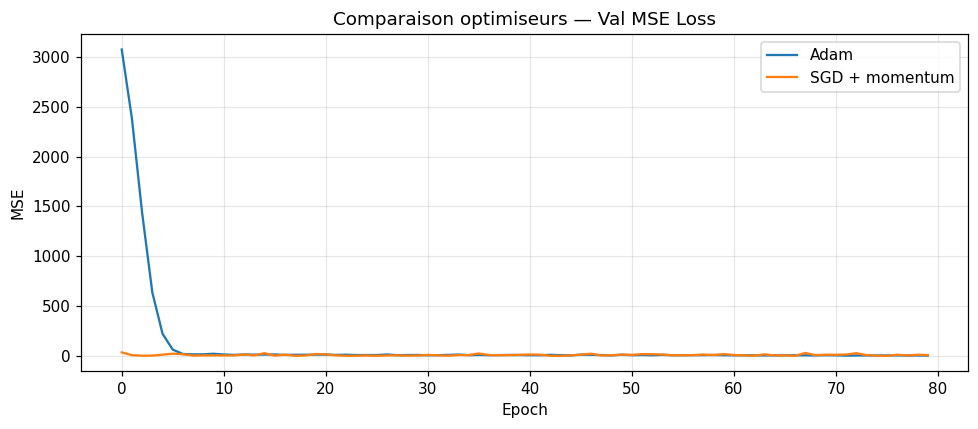

Justification : Adam converge plus rapidement grâce à l'adaptation du learning rate par paramètre.


In [7]:
import torch.nn as nn

def train_with_optimizer(optimizer_name, epochs=100):
    model = MLP(INPUT_DIM, hidden_dims=(128, 64), dropout=0.3)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    if optimizer_name == 'Adam':
        opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    else:
        opt = torch.optim.SGD(model.parameters(), lr=1e-2, momentum=0.9, weight_decay=1e-4)
    criterion = nn.MSELoss()
    tl, vl = make_loaders(X_train, y_train, X_test, y_test)
    val_losses = []
    for _ in range(epochs):
        model.train()
        for xb, yb in tl:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            criterion(model(xb), yb).backward()
            opt.step()
        model.eval()
        with torch.no_grad():
            losses = [criterion(model(xb.to(device)), yb.to(device)).item() for xb, yb in vl]
        val_losses.append(np.mean(losses))
    return val_losses

losses_adam = train_with_optimizer('Adam', epochs=80)
losses_sgd = train_with_optimizer('SGD', epochs=80)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(losses_adam, label='Adam')
ax.plot(losses_sgd, label='SGD + momentum')
ax.set_title('Comparaison optimiseurs — Val MSE Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print('Justification : Adam converge plus rapidement grâce à l\'adaptation du learning rate par paramètre.')

## Jalon 7 — Comparaison ML vs DL

### 7.1 Tableau récapitulatif

In [8]:
baseline_ml = joblib.load('../models/baseline_ridge.joblib') if __import__('os').path.exists('../models/baseline_ridge.joblib') else None

# Recharger les métriques ML depuis le notebook 02 (ou recalculer)
from sklearn.linear_model import Ridge
from src.models_ml import train_ridge
ridge_cv = train_ridge(X_train, y_train)
y_pred_ridge = ridge_cv.best_estimator_.predict(X_test)
metrics_ridge = regression_metrics(y_test, y_pred_ridge, 'Ridge (baseline ML)')

all_results = [metrics_ridge, metrics_mlp_base, metrics_mlp_opt]
print(compare_models(all_results))

Ridge — meilleur alpha: 100 | CV R²: 0.7413
                         R²    RMSE     MAE
model                                      
MLP_optimisé         0.9931  0.7628  0.4742
MLP_baseline         0.9903  0.9048  0.7167
Ridge (baseline ML)  0.7389  4.6832  3.3770


### 7.2 Analyse critique

In [9]:
import time

# Temps d'inférence
import torch
X_test_t = torch.tensor(X_test, dtype=torch.float32)

start = time.time()
_ = ridge_cv.best_estimator_.predict(X_test)
t_ridge = time.time() - start

start = time.time()
_ = predict_mlp(model_opt, X_test)
t_mlp = time.time() - start

print('=== Comparaison ML vs DL ===')
print(f'  Ridge  — temps inférence : {t_ridge*1000:.2f} ms')
print(f'  MLP    — temps inférence : {t_mlp*1000:.2f} ms')
print()
print('Analyse critique :')
print('- Ridge est plus rapide à entraîner et à inférer (convexe, solution analytique).')
print('- Le MLP capture des non-linéarités mais nécessite plus de données et de tuning.')
print('- Sur un dataset synthétique bien conditionné, les gains DL peuvent être modestes.')
print('- La vraie valeur du DL s\'exprimera dans le Jalon 8 (LSTM sur séries temporelles).')

=== Comparaison ML vs DL ===
  Ridge  — temps inférence : 0.21 ms
  MLP    — temps inférence : 6.48 ms

Analyse critique :
- Ridge est plus rapide à entraîner et à inférer (convexe, solution analytique).
- Le MLP capture des non-linéarités mais nécessite plus de données et de tuning.
- Sur un dataset synthétique bien conditionné, les gains DL peuvent être modestes.
- La vraie valeur du DL s'exprimera dans le Jalon 8 (LSTM sur séries temporelles).


## Sauvegarde du MLP optimisé

In [10]:
torch.save(model_opt.state_dict(), '../models/mlp_optimise.pt')
# Sauvegarder aussi l'architecture pour le rechargement
import json
arch = {'input_dim': INPUT_DIM, 'hidden_dims': list(best_hidden), 'dropout': best['dropout']}
with open('../models/mlp_arch.json', 'w') as f:
    json.dump(arch, f)
print('MLP optimisé sauvegardé.')

MLP optimisé sauvegardé.
